# Análisis SUBE — AMBA (copia limpia 2026)

Notebook en **dos partes** (el modelo va aparte, lo vemos después):

1. **Ingesta y limpieza** — baja SUBE, agrega feriados y **tarifas**, graba en `parquet`.
2. **Análisis descriptivo** — totales, pareto, estacionalidad y tarifas.

Cada parte arranca con una *guarda de checkpoint*: si los datos ya están en memoria los usa; si no, los lee del parquet de la Parte 1. Corre 100% de arriba a abajo, o podés saltar directo a la Parte 2.

> **Fuera de scope** en esta versión: radares de tráfico y datos georeferenciados (barrios/paradas/mapas). El foco es SUBE + tarifas.

## 0. Setup

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
SUBE_PARQUET = DATA_DIR / "sube_clean.parquet"
FERIADOS_PARQUET = DATA_DIR / "feriados.parquet"

# Años a descargar (2026 incluido; el loop saltea años que aún no existan)
YEARS = range(2020, 2027)

In [21]:
# El parquet necesita pyarrow. Si te falta, descomentá:
# !pip install -q pyarrow

### URLs

In [22]:
# SUBE: un archivo por año; {} se reemplaza con el año vía .format()
url_sube = "https://archivos-datos.transporte.gob.ar/upload/Dat_Ab_Usos/dat-ab-usos-{}.csv"

# Tarifas (boleto mínimo) por modo, desde el repo
_base = "https://raw.githubusercontent.com/mstainoh/intro-python-analytics-scm/main/data/analisis_sube"
PRECIOS_URLS = {
    "COLECTIVO": f"{_base}/precio_colectivo.csv",
    "SUBTE":     f"{_base}/precio_subte.csv",
    "TREN":      f"{_base}/precio_tren.csv",
}
IPC_URL = f"{_base}/ipc.csv"   # IPC mensual (índice de nivel) para deflactar

# Parte 1 — Ingesta y limpieza

## 1.1 SUBE — descarga

In [23]:
def descargar_sube(years, url_template):
    """Descarga y concatena los CSV anuales de SUBE.
    Saltea con aviso cualquier año que no exista todavía (p.ej. el corriente)."""
    partes = []
    for year in years:
        url = url_template.format(year)
        try:
            print(f"Leyendo {year} ...", end=" ", flush=True)
            df = pd.read_csv(url)
            print(f"OK  ({len(df):,} filas)")
            partes.append(df)
        except Exception as e:
            print(f"SALTADO ({type(e).__name__})")
    if not partes:
        raise RuntimeError("No se pudo leer ningún año de SUBE. Revisá conexión/URLs.")
    return pd.concat(partes, ignore_index=True)

df_sube_raw = descargar_sube(YEARS, url_sube)
print("\nTotal filas:", f"{len(df_sube_raw):,}")
df_sube_raw.head(2)

Leyendo 2020 ... OK  (356,628 filas)
Leyendo 2021 ... OK  (407,730 filas)
Leyendo 2022 ... OK  (439,299 filas)
Leyendo 2023 ... OK  (472,223 filas)
Leyendo 2024 ... OK  (504,631 filas)
Leyendo 2025 ... OK  (541,557 filas)
Leyendo 2026 ... OK  (266,011 filas)

Total filas: 2,988,079


,DIA_TRANSPORTE,NOMBRE_EMPRESA,LINEA,AMBA,TIPO_TRANSPORTE,JURISDICCION,PROVINCIA,MUNICIPIO,CANTIDAD,DATO_PRELIMINAR
0,2020-01-01,EMPRESA BATAN S.A.,BS_AS_LINEA 715M,NO,COLECTIVO,MUNICIPAL,BUENOS AIRES,GENERAL PUEYRREDON,2154,NO
1,2020-01-01,COMPAÑIA DE TRANSPORTE VECINAL S.A.,BS_AS_LINEA_326,SI,COLECTIVO,PROVINCIAL,BUENOS AIRES,SN,1492,NO


## 1.2 SUBE — limpieza

In [24]:
df_sube = df_sube_raw.rename(columns=str.lower)

df_sube["fecha"]   = pd.to_datetime(df_sube["dia_transporte"])
df_sube["es_amba"] = df_sube["amba"] == "SI"

# número de línea (para pareto / agrupaciones); sin número -> 0
df_sube["n_linea"] = pd.to_numeric(
    df_sube["linea"].str.extract(r"([0-9]+)")[0], errors="coerce"
).fillna(0).astype(int)

print(df_sube.columns.tolist())
df_sube.head(2)

['dia_transporte', 'nombre_empresa', 'linea', 'amba', 'tipo_transporte', 'jurisdiccion', 'provincia', 'municipio', 'cantidad', 'dato_preliminar', 'fecha', 'es_amba', 'n_linea']


,dia_transporte,nombre_empresa,linea,amba,tipo_transporte,jurisdiccion,provincia,municipio,cantidad,dato_preliminar,fecha,es_amba,n_linea
0,2020-01-01,EMPRESA BATAN S.A.,BS_AS_LINEA 715M,NO,COLECTIVO,MUNICIPAL,BUENOS AIRES,GENERAL PUEYRREDON,2154,NO,2020-01-01,False,715
1,2020-01-01,COMPAÑIA DE TRANSPORTE VECINAL S.A.,BS_AS_LINEA_326,SI,COLECTIVO,PROVINCIAL,BUENOS AIRES,SN,1492,NO,2020-01-01,True,326


## 1.3 Feriados

Lista curada 2020–2026, **incluidos los puentes por decreto** (que las librerías automáticas suelen errar). Para años futuros, agregar fechas abajo.

In [25]:
holiday_dates = [
    '2020-01-01',  # New Year's Day
    '2020-02-24',  # Carnival
    '2020-02-25',  # Carnival
    '2020-03-24',  # Day of Remembrance for Truth and Justice
    '2020-04-02',  # Malvinas Day
    '2020-04-09',  # Holy Thursday
    '2020-04-10',  # Good Friday
    '2020-05-01',  # Labor Day
    '2020-05-25',  # National Day
    '2020-06-15',  # Güemes Day
    '2020-06-20',  # National Flag Day
    '2020-07-09',  # Independence Day
    '2020-12-07',  # Bridge Holiday
    '2020-12-08',  # Immaculate Conception Day
    '2020-12-25',  # Christmas Day
    '2021-01-01',  # New Year's Day
    '2021-02-15',  # Carnival
    '2021-02-16',  # Carnival
    '2021-03-24',  # Day of Remembrance for Truth and Justice
    '2021-04-01',  # Holy Thursday
    '2021-04-02',  # Malvinas Day / Good Friday
    '2021-05-01',  # Labor Day
    '2021-05-24',  # Bridge Holiday
    '2021-05-25',  # National Day
    '2021-06-21',  # National Flag Day (observed)
    '2021-07-09',  # Independence Day
    '2021-08-16',  # San Martin Day (observed)
    '2021-10-08',  # Bridge Holiday
    '2021-10-11',  # Cultural Diversity Day (observed)
    '2021-11-22',  # National Sovereignty Day (observed)
    '2021-12-08',  # Immaculate Conception Day
    '2021-12-25',  # Christmas Day
    '2022-01-01',  # New Year's Day
    '2022-02-28',  # Carnival
    '2022-03-01',  # Carnival
    '2022-03-24',  # Day of Remembrance for Truth and Justice
    '2022-04-14',  # Holy Thursday
    '2022-04-15',  # Good Friday
    '2022-05-01',  # Labor Day
    '2022-05-25',  # National Day
    '2022-06-17',  # Güemes Day
    '2022-06-20',  # National Flag Day
    '2022-07-09',  # Independence Day
    '2022-08-15',  # San Martin Day (observed)
    '2022-10-07',  # Bridge Holiday
    '2022-10-10',  # Cultural Diversity Day (observed)
    '2022-11-21',  # National Sovereignty Day (observed)
    '2022-12-08',  # Immaculate Conception Day
    '2022-12-09',  # Bridge Holiday
    '2022-12-25',  # Christmas Day
    '2023-01-01',  # New Year's Day
    '2023-02-20',  # Carnival
    '2023-02-21',  # Carnival
    '2023-03-24',  # Day of Remembrance for Truth and Justice
    '2023-04-06',  # Holy Thursday
    '2023-04-07',  # Good Friday
    '2023-05-01',  # Labor Day
    '2023-05-25',  # National Day
    '2023-05-26',  # Bridge Holiday
    '2023-06-19',  # Güemes Day (observed)
    '2023-06-20',  # National Flag Day
    '2023-07-09',  # Independence Day
    '2023-08-21',  # San Martin Day (observed)
    '2023-10-13',  # Bridge Holiday
    '2023-10-16',  # Cultural Diversity Day (observed)
    '2023-11-20',  # National Sovereignty Day
    '2023-12-08',  # Immaculate Conception Day
    '2023-12-25',  # Christmas Day
    '2024-01-01',  # New Year's Day
    '2024-02-12',  # Carnival
    '2024-02-13',  # Carnival
    '2024-03-28',  # Holy Thursday
    '2024-03-29',  # Good Friday
    '2024-04-01',  # Bridge Holiday
    '2024-04-02',  # Malvinas Day
    '2024-05-01',  # Labor Day
    '2024-05-25',  # National Day
    '2024-06-17',  # Güemes Day
    '2024-06-20',  # National Flag Day
    '2024-06-21',  # Bridge Holiday
    '2024-07-09',  # Independence Day
    '2024-08-17',  # San Martin Day
    '2024-10-11',  # Bridge Holiday
    '2024-10-12',  # Cultural Diversity Day
    '2024-11-18',  # National Sovereignty Day
    '2024-12-08',  # Immaculate Conception Day
    '2024-12-25',  # Christmas Day
    '2025-01-01',  # New Year's Day
    '2025-03-03',  # Carnival
    '2025-03-04',  # Carnival
    '2025-03-24',  # Day of Remembrance for Truth and Justice
    '2025-04-02',  # Malvinas Day
    '2025-04-17',  # Holy Thursday
    '2025-04-18',  # Good Friday
    '2025-05-01',  # Labor Day
    '2025-05-02',  # Bridge Holiday
    '2025-05-25',  # National Day
    '2025-06-16',  # Güemes Day (observed)
    '2025-06-20',  # National Flag Day
    '2025-07-09',  # Independence Day
    '2025-08-15',  # Bridge Holiday
    '2025-08-17',  # San Martin Day
    '2025-10-12',  # Cultural Diversity Day
    '2025-11-21',  # Bridge Holiday
    '2025-11-24',  # National Sovereignty Day (observed)
    '2025-12-08',  # Immaculate Conception Day
    '2025-12-25',  # Christmas Day
    '2026-01-01',  # New Year's Day
    '2026-02-16',  # Carnival
    '2026-02-17',  # Carnival
    '2026-03-23',  # Bridge Holiday
    '2026-03-24',  # Day of Remembrance for Truth and Justice
    '2026-04-02',  # Malvinas Day / Holy Thursday
    '2026-04-03',  # Good Friday
    '2026-05-01',  # Labor Day
    '2026-05-25',  # National Day
    '2026-06-15',  # Güemes Day (observed)
    '2026-06-20',  # National Flag Day
    '2026-07-09',  # Independence Day
    '2026-08-17',  # San Martin Day
    '2026-10-12',  # Cultural Diversity Day
    '2026-11-23',  # National Sovereignty Day (observed)
    '2026-12-07',  # Bridge Holiday
    '2026-12-08',  # Immaculate Conception Day
    '2026-12-25',  # Christmas Day
]

In [26]:
holiday_dates = pd.to_datetime(pd.Series(holiday_dates))
df_sube["es_feriado"] = df_sube["fecha"].isin(holiday_dates)
print("Proporción de registros en feriado:", round(df_sube["es_feriado"].mean(), 3))

Proporción de registros en feriado: 0.043


## 1.4 Tarifas (nominal y real)

Series de tarifa (boleto mínimo) por modo + IPC mensual. Con `merge_asof` se asigna la **tarifa vigente** (`tarifa`) y, deflactando por IPC, la **tarifa en pesos constantes de ene-2020** (`tarifa_real = tarifa × IPC_ene2020 / IPC_mes`). Ambas quedan en el parquet, listas para la Parte 3.

In [27]:
def cargar_precios(urls):
    """Lee las series de tarifa por modo y devuelve un df largo ordenado por fecha.
    Robusto a filas basura (fechas no parseables se descartan)."""
    partes = []
    for tipo, url in urls.items():
        p = pd.read_csv(url)
        p["fecha_desde"] = pd.to_datetime(p["fecha_desde"], errors="coerce")
        p = p.dropna(subset=["fecha_desde"])
        p["tipo_transporte"] = tipo
        partes.append(p[["tipo_transporte", "fecha_desde", "valor_ars"]])
    return pd.concat(partes, ignore_index=True).sort_values("fecha_desde")

try:
    # 1) tarifa nominal vigente por modo
    precios = cargar_precios(PRECIOS_URLS)
    tmp = pd.merge_asof(
        df_sube.sort_values("fecha"), precios,
        left_on="fecha", right_on="fecha_desde",
        by="tipo_transporte", direction="backward",
    )
    df_sube = tmp.drop(columns="fecha_desde").rename(columns={"valor_ars": "tarifa"})

    # 2) IPC mensual -> tarifa real (pesos constantes de ene-2020)
    ipc = pd.read_csv(IPC_URL)[["fecha", "ipc"]]
    ipc["fecha"] = pd.to_datetime(ipc["fecha"])
    ipc = ipc.sort_values("fecha")
    ipc_base = ipc.loc[ipc["fecha"] == "2020-01-01", "ipc"].iloc[0]

    # backward: a cada día le toca el IPC de su mes (los meses sin IPC publicado
    # usan el último disponible, p.ej. fin de 2026)
    df_sube = pd.merge_asof(df_sube.sort_values("fecha"), ipc, on="fecha", direction="backward")
    df_sube["tarifa_real"] = df_sube["tarifa"] * ipc_base / df_sube["ipc"]

    cov = df_sube.groupby("tipo_transporte")["tarifa"].apply(lambda s: s.notna().mean())
    print("Cobertura de tarifa por tipo_transporte (1.0 = todo cubierto):")
    print(cov.sort_values(ascending=False).round(2))
except Exception as e:
    print("Precios/IPC no cargados:", repr(e), "-> tarifa = NaN")
    df_sube["tarifa"] = np.nan
    df_sube["tarifa_real"] = np.nan

Cobertura de tarifa por tipo_transporte (1.0 = todo cubierto):
tipo_transporte
COLECTIVO    1.0
SUBTE        1.0
TREN         1.0
LANCHAS      0.0
Name: tarifa, dtype: float64


## 1.5 Guardar checkpoint (parquet)

In [28]:
df_sube.to_parquet(SUBE_PARQUET, index=False)
pd.DataFrame({"fecha": holiday_dates}).to_parquet(FERIADOS_PARQUET, index=False)
print(f"Guardado: {SUBE_PARQUET}  ({SUBE_PARQUET.stat().st_size/1e6:.1f} MB)")
print(f"Guardado: {FERIADOS_PARQUET}")

Guardado: data\sube_clean.parquet  (20.6 MB)
Guardado: data\feriados.parquet


# Parte 2 — Análisis descriptivo

## Checkpoint

Si venís de arriba, `df_sube` ya está en memoria. Si abriste directo acá, se carga del parquet de la Parte 1.

In [29]:
try:
    df_sube
except NameError:
    df_sube = pd.read_parquet(SUBE_PARQUET)
    print("df_sube cargado del checkpoint:", df_sube.shape)

## 2.1 Totales por jurisdicción / tipo de transporte / provincia

In [30]:
print("--- por jurisdicción ---")
print(df_sube.groupby("jurisdiccion")["cantidad"].sum().sort_values(ascending=False), "\n")

print("--- por tipo de transporte ---")
print(df_sube.groupby("tipo_transporte")["cantidad"].sum().sort_values(ascending=False), "\n")

print("--- por provincia (top 10) ---")
df_sube.groupby("provincia")["cantidad"].sum().sort_values(ascending=False).head(10)

--- por jurisdicción ---
jurisdiccion
NACIONAL      8679916769
PROVINCIAL    6874978760
MUNICIPAL     5759562117
C.A.B.A        333633696
Name: cantidad, dtype: int64 

--- por tipo de transporte ---
tipo_transporte
COLECTIVO    19897299864
TREN          1749353554
SUBTE         1034935889
LANCHAS          1437924
Name: cantidad, dtype: int64 

--- por provincia (top 10) ---


provincia
BUENOS AIRES    8943920562
JN              8679916769
MENDOZA         1098520787
SANTA FE         611543214
SAN JUAN         471975816
JUJUY            355491286
C.A.B.A          333633696
ENTRE RÍOS       148699222
CORRIENTES       141223709
NEUQUÉN          140873449
Name: cantidad, dtype: int64

## 2.2 Filtro AMBA

In [31]:
df_amba = df_sube[df_sube.es_amba].copy()
print(f"AMBA: {len(df_amba):,} filas de {len(df_sube):,} ({len(df_amba)/len(df_sube):.0%})")
df_amba["tipo_transporte"].value_counts()

AMBA: 954,726 filas de 2,988,079 (32%)


tipo_transporte
COLECTIVO    899473
TREN          38625
SUBTE         16628
Name: count, dtype: int64

## 2.3 Pareto de líneas de colectivo (AMBA)

196 líneas concentran el 80% de los viajes en colectivo (de 484 líneas).


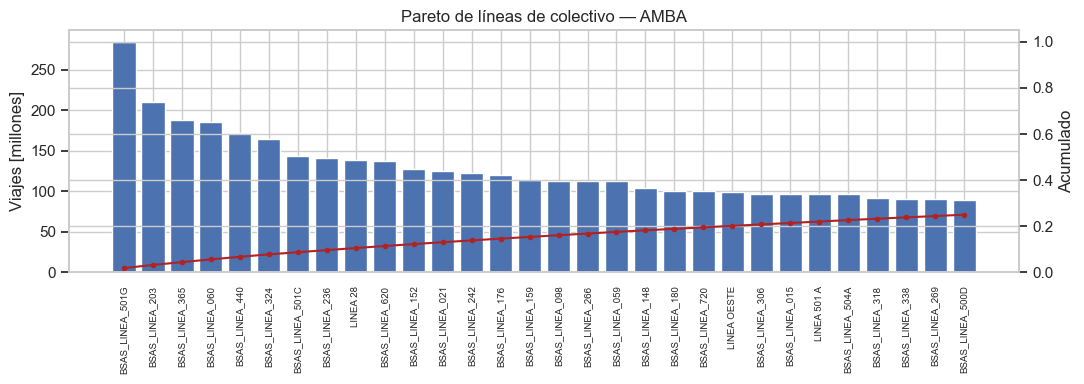

In [32]:
colectivos = df_amba[df_amba.tipo_transporte == "COLECTIVO"]
pareto = colectivos.groupby("linea")["cantidad"].sum().sort_values(ascending=False)

acum = pareto.cumsum() / pareto.sum()
n80 = int((acum <= 0.8).sum()) + 1
print(f"{n80} líneas concentran el 80% de los viajes en colectivo (de {len(pareto)} líneas).")

top = pareto.head(30)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(top)), np.asarray(top.values, float) / 1e6)
ax.set_xticks(range(len(top))); ax.set_xticklabels(top.index, rotation=90, fontsize=7)
ax.set_ylabel("Viajes [millones]")
ax2 = ax.twinx()
ax2.plot(range(len(top)), (top.cumsum() / pareto.sum()).values, color="firebrick", marker=".")
ax2.set_ylim(0, 1.05); ax2.set_ylabel("Acumulado")
ax.set_title("Pareto de líneas de colectivo — AMBA")
plt.tight_layout(); plt.show()

## 2.4 Estacionalidad semanal por tipo de transporte (AMBA)

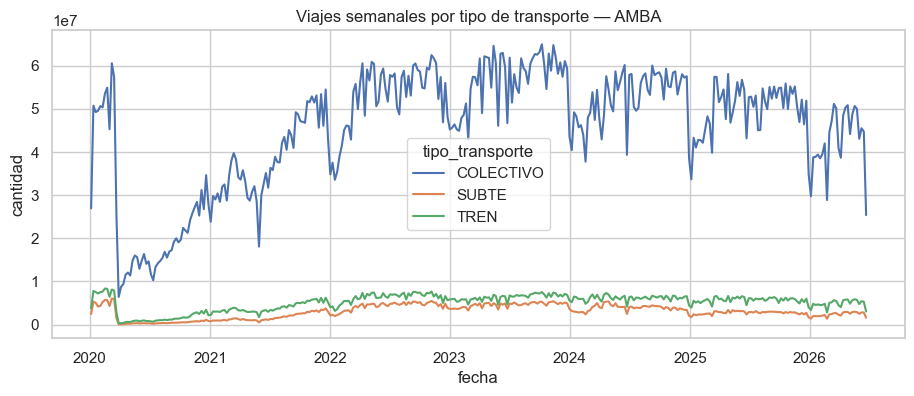

In [33]:
g = df_amba.groupby(["fecha", "tipo_transporte"])["cantidad"].sum().reset_index()
g["dia_semana"] = g["fecha"].dt.weekday

sem = (g.groupby([pd.Grouper(key="fecha", freq="W"), "tipo_transporte"])["cantidad"]
         .sum().reset_index())

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=sem, ax=ax, x="fecha", y="cantidad", hue="tipo_transporte")
ax.set_title("Viajes semanales por tipo de transporte — AMBA")
plt.show()

In [34]:
# Perfil por día de la semana (0 = lunes ... 6 = domingo)
(g.pivot_table(index="tipo_transporte", columns="dia_semana",
               values="cantidad", aggfunc="sum")
  .map("{:,.0f}".format))

dia_semana,0,1,2,3,4,5,6
tipo_transporte,,,,,,,
COLECTIVO,"2,421,031,688","2,591,907,939","2,616,729,175","2,601,583,977","2,585,379,052","1,708,275,055","921,596,838"
SUBTE,"165,926,696","182,692,534","183,497,463","186,742,103","177,019,764","91,766,318","47,291,011"
TREN,"286,518,627","305,085,060","306,346,341","308,133,089","303,035,256","175,575,584","63,335,146"


## 2.5 Tarifas

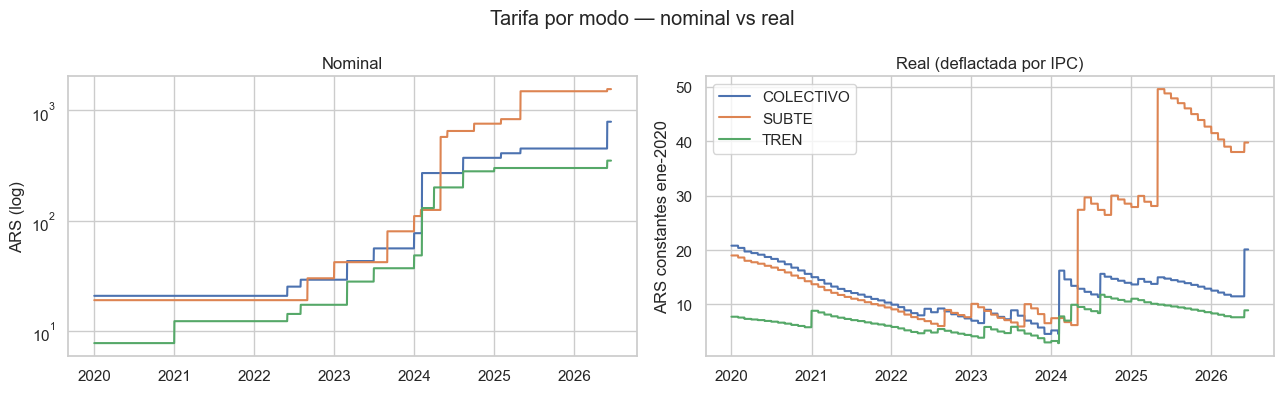

In [35]:
# Evolución de la tarifa por modo: nominal vs real (pesos constantes ene-2020)
tar = (df_sube.groupby(["tipo_transporte", "fecha"])[["tarifa", "tarifa_real"]]
       .first().reset_index().dropna())

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for tipo in tar["tipo_transporte"].unique():
    s = tar[tar["tipo_transporte"] == tipo]
    axes[0].plot(s["fecha"], s["tarifa"], label=tipo)
    axes[1].plot(s["fecha"], s["tarifa_real"], label=tipo)
axes[0].set_yscale("log"); axes[0].set_ylabel("ARS (log)")
axes[0].set_title("Nominal")
axes[1].set_ylabel("ARS constantes ene-2020")
axes[1].set_title("Real (deflactada por IPC)")
axes[1].legend()
fig.suptitle("Tarifa por modo — nominal vs real")
plt.tight_layout(); plt.show()

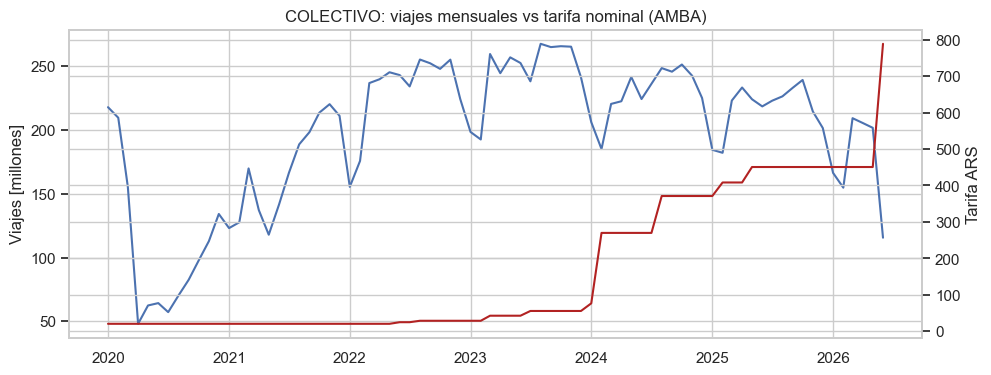

In [36]:
# Viajes mensuales vs tarifa nominal (AMBA, un modo)
mode = "COLECTIVO"
m = (df_amba[df_amba.tipo_transporte == mode]
     .groupby(pd.Grouper(key="fecha", freq="MS"))
     .agg(viajes=("cantidad", "sum"), tarifa=("tarifa", "last"))
     .reset_index())

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(m["fecha"], m["viajes"] / 1e6, label="viajes")
ax.set_ylabel("Viajes [millones]")
ax2 = ax.twinx()
ax2.plot(m["fecha"], m["tarifa"], color="firebrick", label="tarifa")
ax2.set_ylabel("Tarifa ARS")
ax.set_title(f"{mode}: viajes mensuales vs tarifa nominal (AMBA)")
plt.show()

## 2.6 Matriz de correlación

Sobre la serie diaria de **subte** (AMBA). Usa `tarifa_real` (no la nominal: la nominal sube por inflación junto con la recuperación de viajes → correlación espuria). Aun con la real, la tendencia común contamina la relación viajes~precio; sirve como vistazo, no como causalidad.

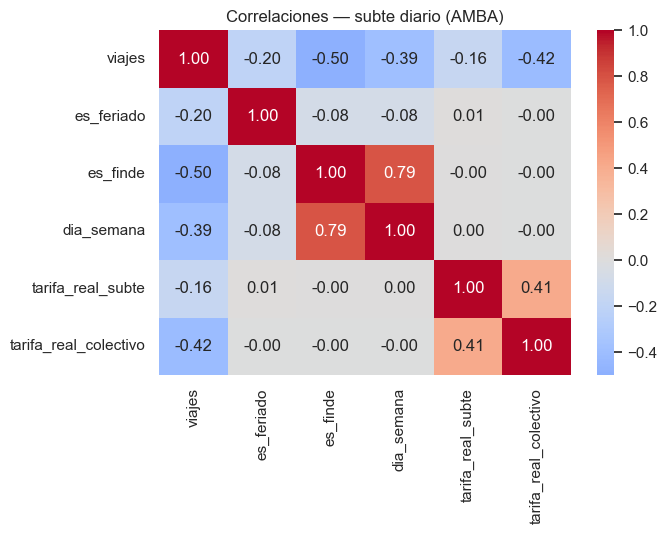

In [37]:
sb = (df_amba[df_amba.tipo_transporte == "SUBTE"].groupby("fecha")
      .agg(viajes=("cantidad", "sum"),
           es_feriado=("es_feriado", "first"),
           tarifa_real_subte=("tarifa_real", "first")).reset_index())
col_real = (df_amba[df_amba.tipo_transporte == "COLECTIVO"]
            .groupby("fecha")["tarifa_real"].first().rename("tarifa_real_colectivo"))
sb = sb.merge(col_real, on="fecha", how="left")
sb["es_finde"]   = (sb["fecha"].dt.weekday >= 5).astype(int)
sb["dia_semana"] = sb["fecha"].dt.weekday

cols = ["viajes", "es_feriado", "es_finde", "dia_semana", "tarifa_real_subte", "tarifa_real_colectivo"]
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(sb[cols].astype(float).corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlaciones — subte diario (AMBA)")
plt.tight_layout(); plt.show()

# Parte 3 — Modelo predictivo

**Target:** viajes diarios de **subte** (AMBA). **Features:** día de la semana, mes, feriado, tendencia y las **tarifas reales de los tres modos** (subte/colectivo/tren), que codifican el precio relativo.

**Validación:** split temporal — entreno 2022–2025, testeo 2026 (nunca aleatorio). Comparo tres modelos:
1. *baseline estacional* (promedio por día-semana × mes × feriado) — benchmark honesto.
2. *log-lineal* — interpretable; los coeficientes de las log-tarifas son elasticidades.
3. *gradient boosting* — más flexible, pero **no extrapola** tendencia ni tarifas fuera del rango de train.

## 3.0 Checkpoint

In [38]:
try:
    df_sube
except NameError:
    df_sube = pd.read_parquet(SUBE_PARQUET)
    print("df_sube cargado del checkpoint:", df_sube.shape)

try:
    holiday_dates
except NameError:
    holiday_dates = pd.read_parquet(FERIADOS_PARQUET)["fecha"]
    print("feriados cargados del checkpoint:", len(holiday_dates))

## 3.1 Construcción del dataset

Serie diaria de subte + una columna por tarifa real de cada modo. Recorto a **2022+** (saca el pozo de pandemia, que es un quiebre estructural).

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

MODO      = "SUBTE"
TRAIN_END = "2025-12-31"     # train: 2022..2025  |  test: 2026+

# target diario
serie = (df_sube[(df_sube.es_amba) & (df_sube.tipo_transporte == MODO)]
         .groupby("fecha")
         .agg(viajes=("cantidad", "sum"), es_feriado=("es_feriado", "first"))
         .reset_index())
assert len(serie), f"no hay datos para {MODO}"

# tarifas reales: una columna por modo
fares = (df_sube.groupby(["fecha", "tipo_transporte"])["tarifa_real"].first()
         .unstack("tipo_transporte"))
fares = fares.rename(columns={c: f"fare_{c.lower()}" for c in fares.columns})
fares = fares[[c for c in ["fare_subte", "fare_colectivo", "fare_tren"] if c in fares.columns]].reset_index()

df = serie.merge(fares, on="fecha", how="left")
df["dia_semana"] = df["fecha"].dt.weekday
df["es_finde"]   = (df["dia_semana"] >= 5).astype(int)
df["mes"]        = df["fecha"].dt.month
df["es_feriado"] = df["es_feriado"].astype(int)
df["trend"]      = (df["fecha"] - df["fecha"].min()).dt.days

fare_cols = [c for c in ["fare_subte", "fare_colectivo", "fare_tren"] if c in df.columns]
df = df[df["fecha"] >= "2022-01-01"].dropna(subset=["viajes"] + fare_cols).reset_index(drop=True)
for c in fare_cols:
    df[f"log_{c}"] = np.log(df[c])
logfare_cols = [f"log_{c}" for c in fare_cols]

print("Rango:", df["fecha"].min().date(), "->", df["fecha"].max().date(), "| filas:", len(df))
print("Tarifas usadas:", fare_cols)
df.head(3)

Rango: 2022-01-01 -> 2026-06-18 | filas: 1630
Tarifas usadas: ['fare_subte', 'fare_colectivo', 'fare_tren']


,fecha,viajes,es_feriado,fare_subte,fare_colectivo,fare_tren,dia_semana,es_finde,mes,trend,log_fare_subte,log_fare_colectivo,log_fare_tren
0,2022-01-01,54959,1,9.101619,9.963878,5.868149,5,1,1,731,2.208452,2.298966,1.769539
1,2022-01-02,120967,0,9.101619,9.963878,5.868149,6,1,1,732,2.208452,2.298966,1.769539
2,2022-01-03,375171,0,9.101619,9.963878,5.868149,0,0,1,733,2.208452,2.298966,1.769539


## 3.2 Diagnóstico de colinealidad

Las tres tarifas reales se mueven casi juntas en el tiempo. Eso no afecta la *predicción*, pero sí vuelve **inestables los coeficientes individuales** del modelo lineal (las elasticidades de abajo hay que leerlas con pinzas).

In [40]:
print("Correlación entre tarifas reales:")
print(df[fare_cols].corr().round(2))

Correlación entre tarifas reales:
                fare_subte  fare_colectivo  fare_tren
fare_subte            1.00            0.72       0.75
fare_colectivo        0.72            1.00       0.92
fare_tren             0.75            0.92       1.00


## 3.3 Split temporal

In [41]:
train = df[df["fecha"] <= TRAIN_END].copy()
test  = df[df["fecha"] >  TRAIN_END].copy()
print(f"train: {len(train):4d} días  ({train.fecha.min().date()} .. {train.fecha.max().date()})")
print(f"test : {len(test):4d} días  ({test.fecha.min().date()} .. {test.fecha.max().date()})")

cat_cols = ["dia_semana", "mes", "es_feriado"]

train: 1461 días  (2022-01-01 .. 2025-12-31)
test :  169 días  (2026-01-01 .. 2026-06-18)


## 3.4 Modelos

In [42]:
# --- Modelo 1: baseline estacional ---
key   = ["dia_semana", "mes", "es_feriado"]
tabla = train.groupby(key)["viajes"].mean()
gmean = train["viajes"].mean()
pred_base = tabla.reindex(test.set_index(key).index).fillna(gmean).values

# --- Modelo 2: log-lineal (log-log en tarifas -> coeficientes = elasticidades) ---
X_lin = cat_cols + ["trend"] + logfare_cols
pre = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)],
    remainder="passthrough",
)
lin = Pipeline([("pre", pre), ("reg", LinearRegression())])
lin.fit(train[X_lin], np.log(train["viajes"]))
pred_lin = np.exp(lin.predict(test[X_lin]))

# --- Modelo 3: gradient boosting (usa las tarifas en nivel) ---
X_gbm = cat_cols + ["trend"] + fare_cols
gbm = HistGradientBoostingRegressor(random_state=42, max_depth=4,
                                     learning_rate=0.08, max_iter=400)
gbm.fit(train[X_gbm], train["viajes"])
pred_gbm = gbm.predict(test[X_gbm])

In [43]:
# --- Métricas sobre el test (2026) ---
def evalua(y, p):
    return (mean_absolute_error(y, p),
            mean_squared_error(y, p) ** 0.5,
            float(np.mean(np.abs((y - p) / y)) * 100))

y_test = test["viajes"].values
filas = []
for nombre, p in [("baseline", pred_base), ("log-lineal", pred_lin), ("GBM", pred_gbm)]:
    mae, rmse, mape = evalua(y_test, p)
    filas.append({"modelo": nombre, "MAE": mae, "RMSE": rmse, "MAPE_%": round(mape, 2)})
pd.DataFrame(filas)

,modelo,MAE,RMSE,MAPE_%
0,baseline,181589.052593,203942.242820,42214.14
1,log-lineal,26479.636006,43003.726047,27827.12
2,GBM,43082.535728,61045.018890,32173.90


## 3.5 Predicho vs observado (test 2026)

### 3.5.1 - semanal

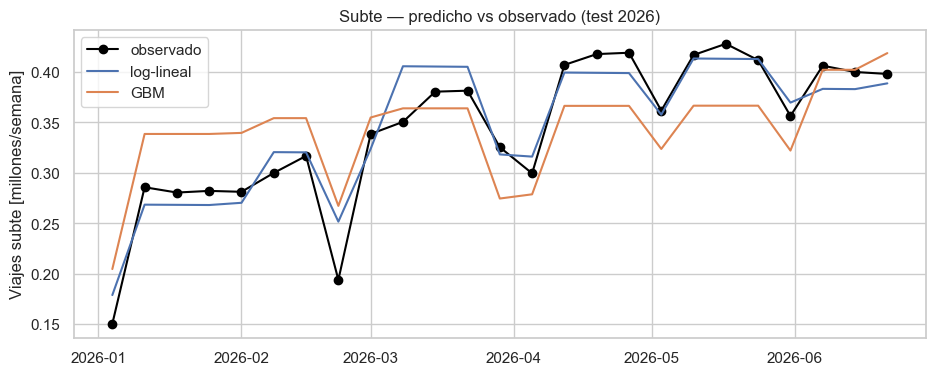

In [ ]:
comp = test[["fecha"]].copy()
comp["observado"]  = y_test
comp["log-lineal"] = pred_lin
comp["GBM"]        = pred_gbm
compW = comp.set_index("fecha").resample("W").mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(compW.fecha, compW["observado"] / 1e6, "o-", color="black", label="observado")
ax.plot(compW.fecha, compW["log-lineal"] / 1e6, label="log-lineal")
ax.plot(compW.fecha, compW["GBM"] / 1e6, label="GBM")
ax.set_ylabel("Viajes subte [millones/semana]"); ax.legend()
ax.set_title("Subte — predicho vs observado (test 2026) - semanal")
plt.show()

### 3.5.2 diario (ultimos datos)

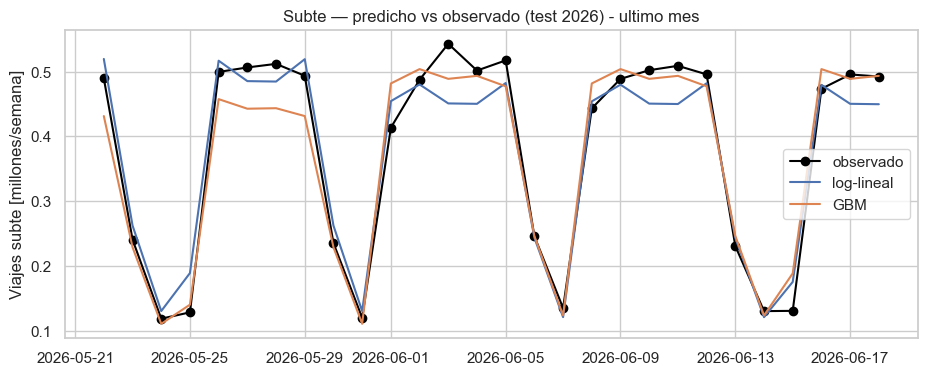

In [54]:

comp = test[["fecha"]].copy()
comp["observado"]  = y_test
comp["log-lineal"] = pred_lin
comp["GBM"]        = pred_gbm
compD = comp[comp['fecha'] > comp['fecha'].max() - pd.Timedelta(weeks=4)]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(compD.fecha, compD["observado"] / 1e6, "o-", color="black", label="observado")
ax.plot(compD.fecha, compD["log-lineal"] / 1e6, label="log-lineal")
ax.plot(compD.fecha, compD["GBM"] / 1e6, label="GBM")
ax.set_ylabel("Viajes subte [millones/semana]"); ax.legend()
ax.set_title("Subte — predicho vs observado (test 2026) - ultimo mes")
plt.show()

### 3.5.3 metricas y xplot

In [50]:
# --- Métricas estándar sobre el test 2026 (diario) ---
from sklearn.metrics import (
    mean_absolute_error as MAE, 
    r2_score as R2, 
    mean_absolute_percentage_error as MAPE, 
    root_mean_squared_error as RMSE,
    )
def metricas(y, p):
    err = p - y
    return {
        "bias":    err.mean(),                  # sesgo: + sobrepredice, - subpredice
        "bias_%":  err.mean() / y.mean() * 100,
        "MAE":     MAE(p, y),
        "RMSE":    RMSE(p, y),
        "R2_%":    R2(p, y) * 100,
        "MAPE_%":  MAPE(p, y) * 100,
    }

tabla_m = pd.DataFrame({
    "log-lineal": metricas(y_test, pred_lin),
    "GBM":        metricas(y_test, pred_gbm),
}).T
print(tabla_m.round(2).to_string())

               bias  bias_%       MAE      RMSE   R2_%  MAPE_%
log-lineal  1767.66    0.51  26479.64  43003.73  90.80    8.80
GBM         -733.32   -0.21  43082.54  61045.02  80.71   12.72


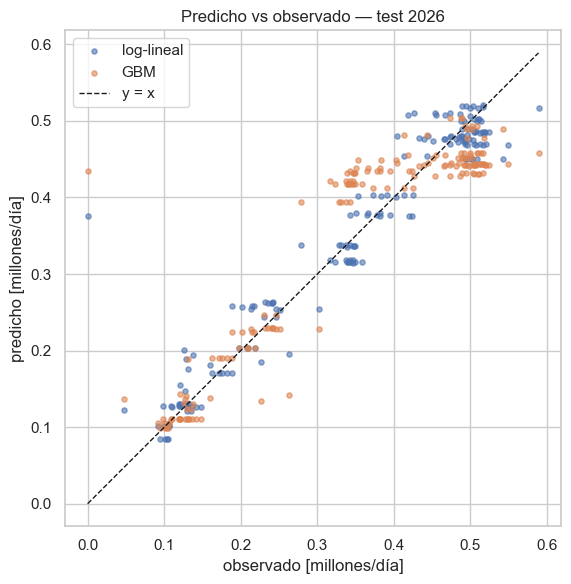

In [49]:
# --- Cross-plot: predicho vs observado (diario, test 2026) ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test / 1e6, pred_lin / 1e6, s=14, alpha=0.6, label="log-lineal")
ax.scatter(y_test / 1e6, pred_gbm / 1e6, s=14, alpha=0.6, label="GBM")

lo = min(y_test.min(), pred_lin.min(), pred_gbm.min()) / 1e6
hi = max(y_test.max(), pred_lin.max(), pred_gbm.max()) / 1e6
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")

ax.set_xlabel("observado [millones/día]")
ax.set_ylabel("predicho [millones/día]")
ax.set_aspect("equal"); ax.legend()
ax.set_title("Predicho vs observado — test 2026")
plt.tight_layout(); plt.show()

## 3.6 Elasticidades y what-if de precio

Los coeficientes de las log-tarifas son elasticidades (Δ% viajes por Δ% tarifa). **Recordatorio:** por la colinealidad y la poca variación de precio (pocos escalones), son *ilustrativas*, no causales. El event-study de abajo es el chequeo cruzado.

In [45]:
names = lin.named_steps["pre"].get_feature_names_out()
coefs = pd.Series(lin.named_steps["reg"].coef_, index=names)
elast = coefs[[c for c in coefs.index if "log_fare" in c]]
elast.index = [c.replace("remainder__log_fare_", "") for c in elast.index]
print("Elasticidades (Δ% viajes subte por Δ% tarifa):")
print(elast.round(3).to_string(), "\n")

e_subte = elast.get("subte", np.nan)
e_col   = elast.get("colectivo", np.nan)
print("What-if:")
for ch in [0.15, 0.30, 0.50]:
    d_own   = e_subte * np.log(1 + ch) * 100
    d_cross = e_col   * np.log(1 + ch) * 100
    print(f"  tarifa subte +{ch:.0%}      ->  viajes subte {d_own:+.1f}%")
    print(f"  tarifa colectivo +{ch:.0%}  ->  viajes subte {d_cross:+.1f}%  (sustitución)")

Elasticidades (Δ% viajes subte por Δ% tarifa):
subte       -0.209
colectivo   -0.287
tren         0.208 

What-if:
  tarifa subte +15%      ->  viajes subte -2.9%
  tarifa colectivo +15%  ->  viajes subte -4.0%  (sustitución)
  tarifa subte +30%      ->  viajes subte -5.5%
  tarifa colectivo +30%  ->  viajes subte -7.5%  (sustitución)
  tarifa subte +50%      ->  viajes subte -8.5%
  tarifa colectivo +50%  ->  viajes subte -11.6%  (sustitución)


In [ ]:
# Event-study: mayor salto de tarifa real del subte (chequeo de la elasticidad propia)
fs = df[["fecha", "fare_subte"]].drop_duplicates("fare_subte").sort_values("fecha")
fs["pct"] = fs["fare_subte"].pct_change()
ev = fs.loc[fs["pct"].idxmax(), "fecha"]
w = 28  # ventana en días
mask_h = df["es_finde"] == 0
antes = df[mask_h & (df.fecha <  ev) & (df.fecha >= ev - pd.Timedelta(days=w))]["viajes"].mean()
desp  = df[mask_h & (df.fecha >= ev) & (df.fecha <  ev + pd.Timedelta(days=w))]["viajes"].mean()
print(f"Mayor salto de tarifa real subte: {ev.date()} (+{fs['pct'].max():.0%})")
print(f"Viajes días hábiles  4 sem antes: {antes:,.0f}  |  4 sem después: {desp:,.0f}  "
      f"|  cambio: {(desp/antes - 1)*100:+.1f}%")
print("(lectura cruda, sin controlar estación: tomar como orden de magnitud)")

Mayor salto de tarifa real subte: 2024-05-01 (+341%)
Viajes días hábiles  4 sem antes: 925,139  |  4 sem después: 762,942  |  cambio: -17.5%
(lectura cruda, sin controlar estación: tomar como orden de magnitud)


## 3.7 Forecast a futuro (bajo escenario de tarifa)

El calendario y la tendencia se derivan solos para fechas futuras, pero **la tarifa futura no se conoce** → el pronóstico es bajo un escenario. Acá: mantener la última tarifa real conocida de cada modo (equivale a suponer que las tarifas siguen a la inflación). Uso el **log-lineal** porque extrapola tendencia; el GBM la achataría.

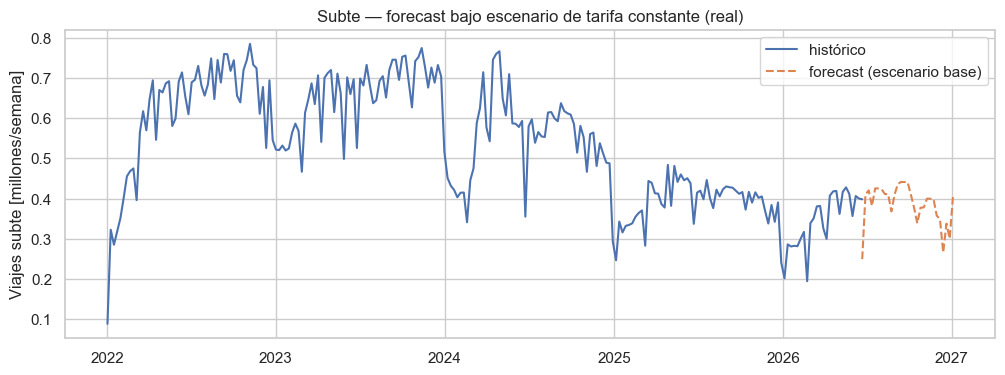

Forecast 2026-06-19 -> 2026-12-31 | media diaria: 388,221


In [47]:
H_END = "2026-12-31"
fut = pd.DataFrame({"fecha": pd.date_range(df["fecha"].max() + pd.Timedelta(days=1), H_END, freq="D")})
fut["dia_semana"] = fut["fecha"].dt.weekday
fut["es_finde"]   = (fut["dia_semana"] >= 5).astype(int)
fut["mes"]        = fut["fecha"].dt.month
fut["trend"]      = (fut["fecha"] - df["fecha"].min()).dt.days
fut["es_feriado"] = fut["fecha"].isin(holiday_dates).astype(int)

# escenario base: última tarifa real conocida de cada modo
ult = {c: df[c].dropna().iloc[-1] for c in fare_cols}
for c in fare_cols:
    fut[c] = ult[c]
    fut[f"log_{c}"] = np.log(ult[c])

fut["pred"] = np.exp(lin.predict(fut[X_lin]))

hist_w = df.set_index("fecha")["viajes"].resample("W").mean()
fut_w  = fut.set_index("fecha")["pred"].resample("W").mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hist_w.index, hist_w.values / 1e6, label="histórico")
ax.plot(fut_w.index, fut_w.values / 1e6, "--", label="forecast (escenario base)")
ax.set_ylabel("Viajes subte [millones/semana]"); ax.legend()
ax.set_title("Subte — forecast bajo escenario de tarifa constante (real)")
plt.show()
print("Forecast", fut.fecha.min().date(), "->", fut.fecha.max().date(),
      "| media diaria:", f"{fut['pred'].mean():,.0f}")